In [10]:
import os
from pathlib import Path
import torch 
import numpy as np

from ml.inference import load_checkpoint


## Variables globales
base = Path.cwd() ## dossier parent 
device = torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu')

def load_pretrain_checkpoint(ckpt_id):
    """
    The ckpt_id is of the form date Y m d - H M S 
    """
    ckpt_dir = Path(os.path.join(base, '..', '..', 'outputs', 'ml', 'pretrain', ckpt_id, 'checkpoints', 'best.pt'))

    device = torch.device("cpu")
    pretrained_model, cfg, mean, scale = load_checkpoint(ckpt_dir, device)
    print(pretrained_model)
    return pretrained_model, cfg, mean, scale


In [11]:
## on charge les poids de l'encoder du modèle préentrainé sur un backbone avec les mêmes paramètres (cf MAEv1.yaml pour l'archi de l'encoder)
from ml.model import VanillaViT

def create_bakcbone_vanillavit(
    pretrained_model, 
    n_features, 
    window_size, 
    patch_size, 
    embed_dim, 
    n_attn_heads, 
    n_blocks, 
    expansion_factor, 
    dropout_rate):
    encoder_sd = pretrained_model.encoder_state_dict() ## donne directement les poids de l'encodeur avec les bons mapping

    backbone_MAE = VanillaViT(
        n_features = n_features, 
        n_epochs= window_size, 
        patch_size=patch_size, 
        embed_dim=embed_dim,
        n_attn_heads=n_attn_heads,
        n_blocks=n_blocks,
        expansion_factor=expansion_factor,
        dropout_rate=dropout_rate
    )
    # missing, unexpected = backbone_MAE.load_state_dict(encoder_sd, strict=False) # les poids sont bien chargés. 
    return backbone_MAE

In [12]:
from ml.datahandler import load_spacetrack_objects, build_features

def load_data_and_inference(backbone, window_size, batch_size=256):
    data_dir = Path(os.path.join(base, '..' , '..', 'data', 'raw', 'spacetrack'))
    objects = load_spacetrack_objects(data_dir, 'leo')

    per_obj = {}
    for key, df in objects.items(): 
        features, feature_cols = build_features(df, spacetrack=True)
        X = (features[feature_cols].to_numpy(np.float32) - mean) / scale
        per_obj[key] = X

    backbone.eval()
    backbone.to(device)

    out = {}
    for norad, X in per_obj.items():
        if len(X) < window_size : 
            continue 
        stride = 24
        windows = np.lib.stride_tricks.sliding_window_view(X, window_size, axis=0)[::stride] # (L,F,W)

        cls_representations = []

        for i in range(0, len(windows), batch_size): 
            x = torch.from_numpy(np.ascontiguousarray(windows[i:i+batch_size])).float().to(device)

            with torch.no_grad(): 
                representation = backbone(x)
            cls_representations.append(representation[:,0,:].cpu().numpy()) ## on ne stocke que le cls token

        if cls_representations:
            out[norad] = np.concatenate(cls_representations, axis=0).mean(axis=0) 
    return out 



In [13]:
import hdbscan
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

## une représentation par objet : token CLS (indice 0) moyenné sur toutes les fenêtres

def scaler_and_clusters_labels(out, min_cluster_size, min_samples):
    norad_ids = list(out.keys())
    X_obj = np.stack([out[n] for n in norad_ids])
    X_scaled = StandardScaler().fit_transform(X_obj)

    clusterer = hdbscan.HDBSCAN(min_cluster_size=20, min_samples=15)

    labels = clusterer.fit_predict(X_scaled)

    n_clusters = len(set(labels))
    return X_scaled, labels

def data_and_labels_cleaned(X_scaled, labels):
    mask=labels!=-1
    X_cleaned = X_scaled[mask]
    labels_cleaned = labels[mask]
    return X_cleaned, labels_cleaned


In [14]:

import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

def viz_3d_on_clusters(X, labels, min_cluster_size=20, min_samples=15):
    """X is a (14 993, 64) ndarray of already scaled vectors, we reduce the dimension from 64 to 3 with principal components analysis, and show the clusters
    """
    pca = PCA(n_components=3)
    X_3d = pca.fit_transform(X)

    df = pd.DataFrame({'x' : X_3d[:,0], 'y' : X_3d[:,1], 'z': X_3d[:,2], 'cluster' : labels.astype(str)})
    
    fig, ax = plt.subplots(figsize=(25,18))

    sns.scatterplot(data=df , x='x',y='y', z = 'z', hue='cluster', palette='husl', s=10, alpha=0.9, legend=False, ax=ax)

    for cluster_id, group in df.groupby('cluster'):
        cx,cy,cz = group['x'].mean(), group['y'].mean(), group['z'].mean()
        ax.annotate(str(cluster_id), (cx,cy,cz), fontsize=8, fontweight='bold', ha='center', va='center', bbox=dict(boxstyle='round,pad=0.2' , fc ='white', ec='black'), alpha = 0.75)

    ax.set_title(f"HDBSCAN Clustering - {len(set(labels))} clusters, {len(labels)} objets - min_cluster_size = {min_cluster_size}, min_samples = {min_samples}")
    ax.set_xlabel("PC1")
    ax.set_ylabel("PC2")
    

    plt.tight_layout()
    plt.show()

def viz_2d_on_clusters(X, labels, min_cluster_size = 20, min_samples=15, plot=True):
    """X is a (14 993, 64) ndarray of already scaled vectors, we reduce the dimension from 64 to 2 with principal components analysis, and show the clusters
    """
    if len(X[0]) > 2 : 
        pca = PCA(n_components=2, svd_solver='full')
        X_2d = pca.fit_transform(X)
    else : 
        X_2d = X
    df = pd.DataFrame({'x' : X_2d[:,0], 'y' : X_2d[:,1], 'cluster' : labels.astype(str)})
    
    fig, ax = plt.subplots(figsize=(25,18))

    sns.scatterplot(data=df , x='x',y='y',hue='cluster', palette='husl', s=10, alpha=0.9, legend=False, ax=ax)

    for cluster_id, group in df.groupby('cluster'):
        cx,cy = group['x'].mean(), group['y'].mean()
        ax.annotate(str(cluster_id), (cx,cy), fontsize=8, fontweight='bold', ha='center', va='center', bbox=dict(boxstyle='round,pad=0.2' , fc ='white', ec='black'), alpha = 0.75)

    ax.set_title(f"HDBSCAN Clustering - {len(set(labels))} clusters, {len(labels)} objets - min_cluster_size = {min_cluster_size}, min_samples = {min_samples}")
    ax.set_xlabel("PC1")
    ax.set_ylabel("PC2")
    
    plt.tight_layout()
    plt.show()



In [15]:
def create_cluster_csv(norad_ids, labels, name):
    # X est un vecteur de dim 64 représentant un unique satellite (moyenne des cls tokens des différentes fenêtres de l'objet)
    df = pd.DataFrame({
        'norad' : norad_ids, 'cluster' : labels
    })
    out_path = Path(base) / '..' / '..' / 'outputs' / 'clustering' / f'cluster_leo_{name}.csv'
    out_path.parent.mkdir(parents=True, exist_ok=True)
    df.to_csv(out_path , index=False)


In [16]:
## on va maintenant tester la bonne généralisation du préentrainement en reproduisant le split train/val avec la seed de config

from ml.dataset import split_by_object

def test_on_split_train_val(out, clusterer):
    norad_ids = list(out.keys())
    train_ids, val_ids = split_by_object(object_ids=norad_ids, val_split=0.2, seed=42)

    X_obj_train = np.stack([out[n] for n in train_ids])
    X_obj_val = np.stack([out[n] for n in val_ids])


    X_scaled_train = StandardScaler().fit_transform(X_obj_train)
    X_scaled_val = StandardScaler().fit_transform(X_obj_val)
    
    labels_train = clusterer.fit_predict(X_scaled_train)
    labels_val = clusterer.fit_predict(X_scaled_val)

    X_scaled_train_clean, labels_train_clean = data_and_labels_cleaned(X_scaled_train, labels_train)

    X_scaled_val_clean, labels_val_clean = data_and_labels_cleaned(X_scaled_val, labels_val)

    viz_2d_on_clusters(X_scaled_train_clean, labels_train_clean)
    viz_2d_on_clusters(X_scaled_val_clean, labels_val_clean)


In [17]:
## on va tester différentes configuration de paramètres HDBSCAN

def hdbscan_params_cluster_test(X):
    score = 0 
    best_minclustersize = 0
    best_minsamples = 0
    for cluster_size in range(2,21,3) : 
        for samples in range(2,21, 3) : 
            clusterer = hdbscan.HDBSCAN(min_cluster_size=cluster_size, min_samples=samples, gen_min_span_tree=True)
            labels = clusterer.fit_predict(X)
            dbcv = clusterer.relative_validity_
            if dbcv > score : 
                score = dbcv
                best_minclustersize = cluster_size
                best_minsamples = samples
    
    clusterer = hdbscan.HDBSCAN(min_cluster_size=best_minclustersize, min_samples=best_minsamples)
    labels = clusterer.fit_predict(X)
    mask = labels !=-1
    X_clean = X[mask]
    labels_clean = labels[mask]
    viz_2d_on_clusters(X_clean, labels_clean, min_cluster_size=cluster_size, min_samples=samples)



In [ ]:
pretrained_model, cfg, mean, scale = load_pretrain_checkpoint('2026-08-11_14-43-36')
backbone = create_bakcbone_vanillavit(pretrained_model, 
                                      n_features=11, 
                                      window_size=192, 
                                      patch_size=12, 
                                      embed_dim=128,
                                      n_attn_heads=4, 
                                      n_blocks=12,
                                      expansion_factor=4,
                                      dropout_rate=0.0)

out = load_data_and_inference(backbone, window_size=192)




TimeSeriesMAE(
  (patch_embedding): PatchEmbedding(
    (proj): Conv1d(11, 128, kernel_size=(12,), stride=(12,))
  )
  (encoder_pos_embedding): LearnedPositionalEmbedding(
    (PE): Embedding(16, 128)
  )
  (decoder_pos_embedding): LearnedPositionalEmbedding(
    (PE): Embedding(17, 64)
  )
  (encoder_blocks): ModuleList(
    (0-11): 12 x TransformerBlock(
      (norm1): LayerNorm((128,), eps=1e-05, elementwise_affine=True, bias=True)
      (norm2): LayerNorm((128,), eps=1e-05, elementwise_affine=True, bias=True)
      (MSA): MultiHeadSelfAttention(
        (query_matrix): Linear(in_features=128, out_features=128, bias=True)
        (key_matrix): Linear(in_features=128, out_features=128, bias=True)
        (value_matrix): Linear(in_features=128, out_features=128, bias=True)
        (output_proj): Linear(in_features=128, out_features=128, bias=True)
        (dropout): Dropout(p=0.0, inplace=False)
      )
      (MLP): MLP(
        (dense1): Linear(in_features=128, out_features=512, bias

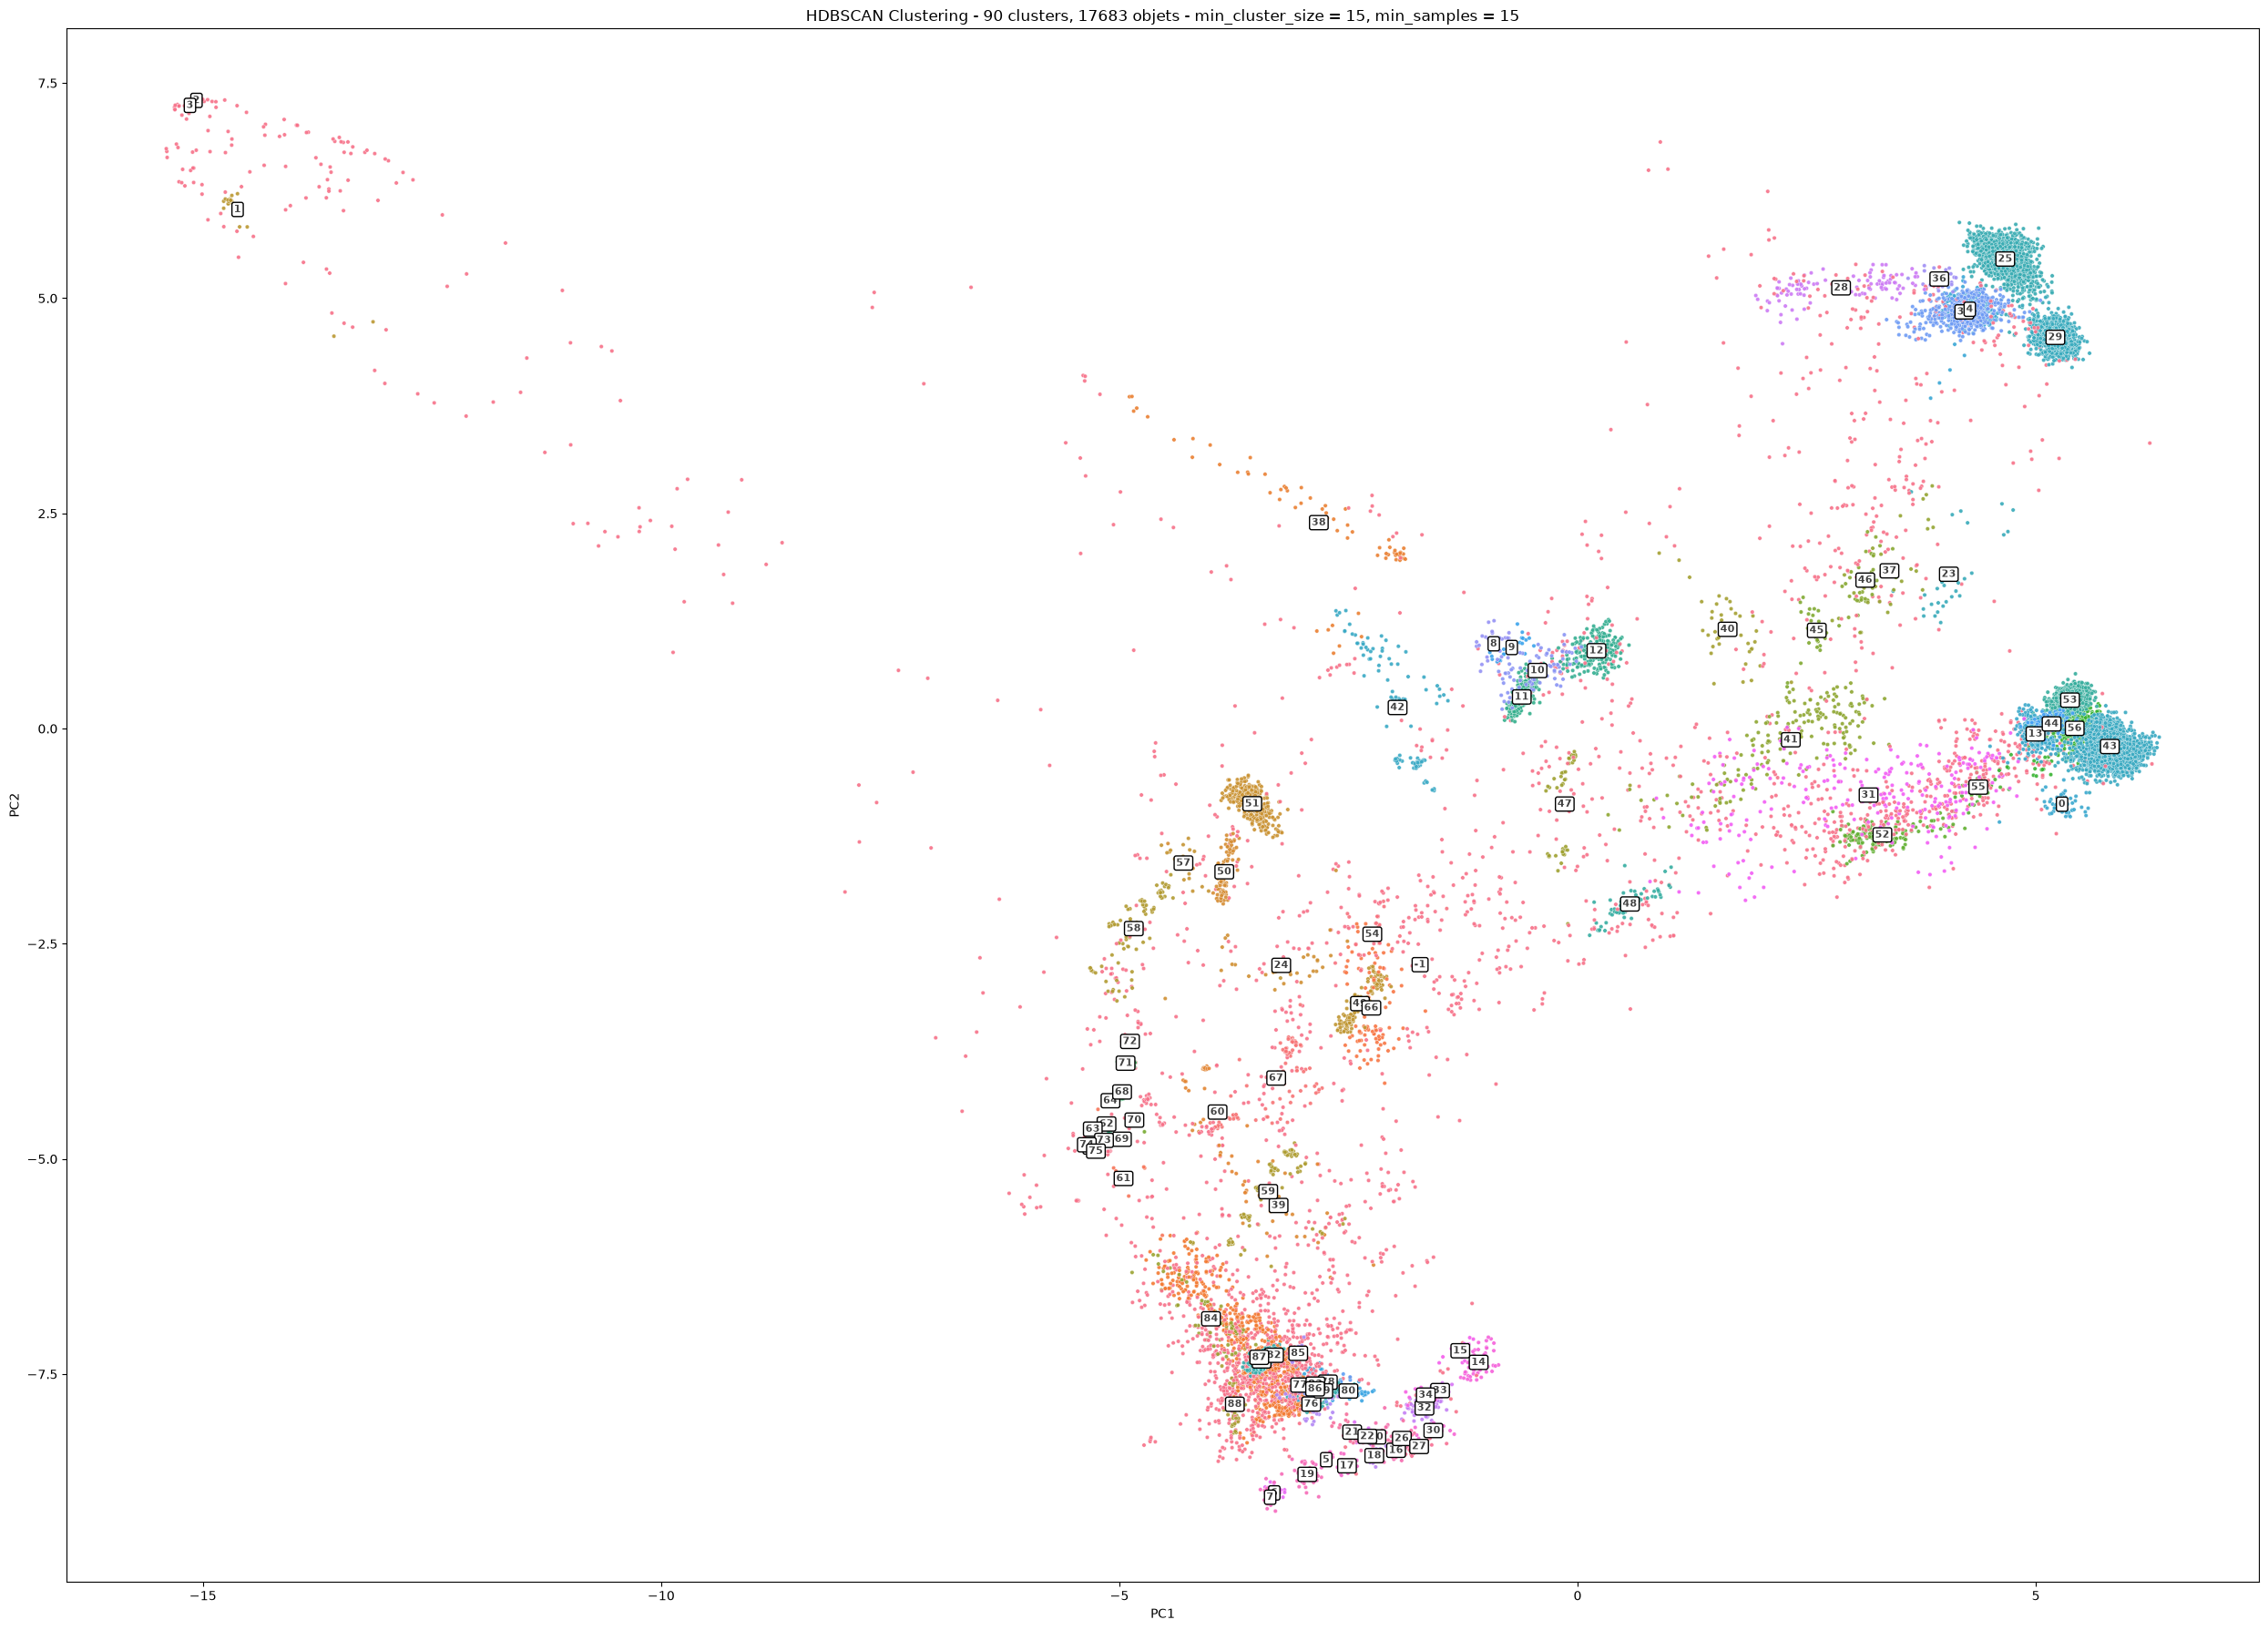

In [ ]:
X_scaled, labels = scaler_and_clusters_labels(out, min_cluster_size=15, min_samples=15)
viz_2d_on_clusters(X_scaled, labels, min_cluster_size=15,min_samples=15)


## Analyse de l'augmentation de la dimension d'embedding 

--- 

Run 128-D : Architecure MAEv2, 15000 objets, sur 200 epochs.

HDBSCAN : après un scan des paramètres 
$$
min cluster size \in \{ 5, \dots, 20 \}  \quad  min samples \in \{ 5, \dots, 15 \}
$$
on retient 15 et 15. 

Par la suite on fait référence à la clusterisation sauvée dans le csv nommé 'cluster_leo_15000_spacetrack_128D_MCS15_MS15_OPTIM

On obtient 75 clusters. + 3384 objets classés en bruit (22%, logiqe)

Structure en 3 étages : 
- les méga-constellations : (9 grands clusters, environ 7900 objets). 
    4 coquilles Starlink dominantes : clusters 65, 50, 67, 48. ainsi que 51 (V2 mini 2025) 66 (V1.0 2020) et 23(polaire/haute inclinaison)
    S'y ajoutent 13 (coquille chinoise Qianfan/Guonwang 2024-2025) et 14 (Starlink 2024). Starlink occupe bien 53% du catalogue réel. 
- les plans orbitaux (15 clusters de 50-60).
    Douzaine de plans OneWeb avec 50-58 objets chacuns qui ressortent clairement 
- les lots de lancements individuels  (15 clusters).
    les lancements Starlink V2 Mini 2025. les 5 lots Qianfan, les lots Kuiper